In [1]:
import sys, warnings
from pathlib import Path
import sqlite3

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold", "axes.titlesize": 13})

# Add scripts/ to sys.path so we can import db_utils and sql_analysis
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))

from db_utils     import get_engine, get_connection, run_query, pretty_print, list_tables, db_summary, table_info
from sql_analysis import *

print("Imports OK.")
print(f"pandas {pd.__version__} | SQLAlchemy installed | sqlite3 {sqlite3.sqlite_version}")


Imports OK.
pandas 3.0.3 | SQLAlchemy installed | sqlite3 3.50.4


In [2]:
DB_PATH = PROJECT_ROOT / "data" / "superstore.db"

# If the database does not exist yet, build it now
if not DB_PATH.exists():
    print("Database not found — running create_database.py ...")
    import subprocess
    result = subprocess.run(
        [sys.executable, str(PROJECT_ROOT / "scripts" / "create_database.py")],
        capture_output=True, text=True
    )
    print(result.stderr)

engine = get_engine(DB_PATH)
print(f"Connected to  {DB_PATH.name}  ({DB_PATH.stat().st_size / 1024:.1f} KB)")


Connected to  superstore.db  (3224.0 KB)


In [3]:
# Verify row counts match Task-1 cleaned dataset
db_summary(engine)


Database Row Counts Summary:
----------------------------
Table: orders     | Rows: 9,799
Table: customers  | Rows: 793
Table: products   | Rows: 1,861
Views: 5
  - vw_customer_summary
  - vw_product_summary
  - vw_monthly_sales
  - vw_category_sales
  - vw_order_summary
----------------------------


In [4]:
list_tables(engine)


 type                name            tbl_name
 view   vw_category_sales   vw_category_sales
 view vw_customer_summary vw_customer_summary
 view    vw_monthly_sales    vw_monthly_sales
 view    vw_order_summary    vw_order_summary
 view  vw_product_summary  vw_product_summary
table           customers           customers
table              orders              orders
table            products            products


,type,name,tbl_name
0,view,vw_category_sales,vw_category_sales
1,view,vw_customer_summary,vw_customer_summary
2,view,vw_monthly_sales,vw_monthly_sales
3,view,vw_order_summary,vw_order_summary
4,view,vw_product_summary,vw_product_summary
5,table,customers,customers
6,table,orders,orders
7,table,products,products


In [5]:
print("=== orders schema ===")
display(table_info("orders", engine))


=== orders schema ===


,cid,name,type,notnull,dflt_value,pk
0,0,row_id,BIGINT,0,None,0
1,1,order_id,TEXT,0,None,0
2,2,order_date,TEXT,0,None,0
3,3,ship_date,TEXT,0,None,0
4,4,ship_mode,TEXT,0,None,0
5,5,customer_id,TEXT,0,None,0
6,6,customer_name,TEXT,0,None,0
7,7,segment,TEXT,0,None,0
8,8,country,TEXT,0,None,0
9,9,city,TEXT,0,None,0


In [6]:
print("=== customers schema ===")
display(table_info("customers", engine))

print("\n=== products schema ===")
display(table_info("products", engine))


=== customers schema ===


,cid,name,type,notnull,dflt_value,pk
0,0,customer_id,TEXT,0,None,0
1,1,customer_name,TEXT,0,None,0
2,2,segment,TEXT,0,None,0



=== products schema ===


,cid,name,type,notnull,dflt_value,pk
0,0,product_id,TEXT,0,None,0
1,1,category,TEXT,0,None,0
2,2,sub_category,TEXT,0,None,0
3,3,product_name,TEXT,0,None,0


In [7]:
# Quick data preview
run_query("SELECT * FROM orders LIMIT 5;", engine=engine)


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,sales,order_year,order_month,order_year_month,order_day_of_week,shipping_days,sales_outlier_flag,sales_capped,shipping_days_outlier_flag,shipping_days_capped
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,261.9600,2017,11,2017-11,Wednesday,3,0,261.960,0,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,731.9400,2017,11,2017-11,Wednesday,3,1,500.558,0,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,14.6200,2017,6,2017-06,Monday,4,0,14.620,0,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,957.5775,2016,10,2016-10,Tuesday,7,1,500.558,0,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,22.3680,2016,10,2016-10,Tuesday,7,0,22.368,0,7


In [8]:
# SELECT chosen columns with a rounded-sales alias
df_select = demo_select(engine=engine)
df_select


,order_id,customer_name,segment,category,sub_category,sales
0,CA-2017-152156,Claire Gute,Consumer,Furniture,Bookcases,261.96
1,CA-2017-152156,Claire Gute,Consumer,Furniture,Chairs,731.94
2,CA-2017-138688,Darrin Van Huff,Corporate,Office Supplies,Labels,14.62
3,US-2016-108966,Sean O'Donnell,Consumer,Furniture,Tables,957.58
4,US-2016-108966,Sean O'Donnell,Consumer,Office Supplies,Storage,22.37
5,CA-2015-115812,Brosina Hoffman,Consumer,Furniture,Furnishings,48.86
6,CA-2015-115812,Brosina Hoffman,Consumer,Office Supplies,Art,7.28
7,CA-2015-115812,Brosina Hoffman,Consumer,Technology,Phones,907.15
8,CA-2015-115812,Brosina Hoffman,Consumer,Office Supplies,Binders,18.50
9,CA-2015-115812,Brosina Hoffman,Consumer,Office Supplies,Appliances,114.90


In [9]:
# Filter orders from the West region, sorted by highest sales
df_where = demo_where(region="West", engine=engine)
df_where


,order_id,customer_name,segment,category,sub_category,sales
0,CA-2018-140151,Raymond Buch,Consumer,Technology,Copiers,13999.96
1,CA-2015-143917,Ken Lonsdale,Consumer,Office Supplies,Supplies,8187.65
2,CA-2018-135909,Jane Waco,Corporate,Office Supplies,Binders,5083.96
3,CA-2017-136301,Edward Hooks,Corporate,Office Supplies,Supplies,4912.59
4,CA-2018-149881,Nick Crebassa,Corporate,Technology,Machines,4799.98
5,CA-2017-138478,Dennis Pardue,Home Office,Office Supplies,Binders,4535.98
6,CA-2017-100300,Max Jones,Consumer,Technology,Machines,4476.80
7,CA-2017-159016,Karen Ferguson,Home Office,Technology,Phones,4158.91
8,CA-2015-168494,Nora Preis,Consumer,Furniture,Tables,3610.85
9,CA-2017-107104,Maribeth Schnelling,Consumer,Furniture,Bookcases,3406.66


In [10]:
# Top 10 highest-value individual order lines across all regions
df_order = demo_order_by(engine=engine)
df_order


,order_id,customer_name,product_name,sales
0,CA-2015-145317,Sean Miller,Cisco TelePresence System EX90 Videoconferenci...,22638.48
1,CA-2017-118689,Tamara Chand,Canon imageCLASS 2200 Advanced Copier,17499.95
2,CA-2018-140151,Raymond Buch,Canon imageCLASS 2200 Advanced Copier,13999.96
3,CA-2018-127180,Tom Ashbrook,Canon imageCLASS 2200 Advanced Copier,11199.97
4,CA-2018-166709,Hunter Lopez,Canon imageCLASS 2200 Advanced Copier,10499.97
5,CA-2017-117121,Adrian Barton,GBC Ibimaster 500 Manual ProClick Binding System,9892.74
6,CA-2015-116904,Sanjit Chand,Ibico EPK-21 Electric Binding System,9449.95
7,US-2017-107440,Bill Shonely,"3D Systems Cube Printer, 2nd Generation, Magenta",9099.93
8,CA-2017-158841,Sanjit Engle,HP Designjet T520 Inkjet Large Format Printer ...,8749.95
9,CA-2017-143714,Christopher Conant,Canon imageCLASS 2200 Advanced Copier,8399.98


In [11]:
# First 5 rows — useful for data exploration
demo_limit(n=5, engine=engine)


,order_id,customer_name,product_name,sales
0,CA-2017-152156,Claire Gute,Bush Somerset Collection Bookcase,261.96
1,CA-2017-152156,Claire Gute,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94
2,CA-2017-138688,Darrin Van Huff,Self-Adhesive Address Labels for Typewriters b...,14.62
3,US-2016-108966,Sean O'Donnell,Bretford CR4500 Series Slim Rectangular Table,957.58
4,US-2016-108966,Sean O'Donnell,Eldon Fold 'N Roll Cart System,22.37


In [12]:
# Total and average sales per product category
df_grp = demo_group_by(engine=engine)
df_grp


,category,total_sales,avg_sale
0,Furniture,728377.20,350.69
1,Office Supplies,705422.33,119.38
2,Technology,827455.87,456.40


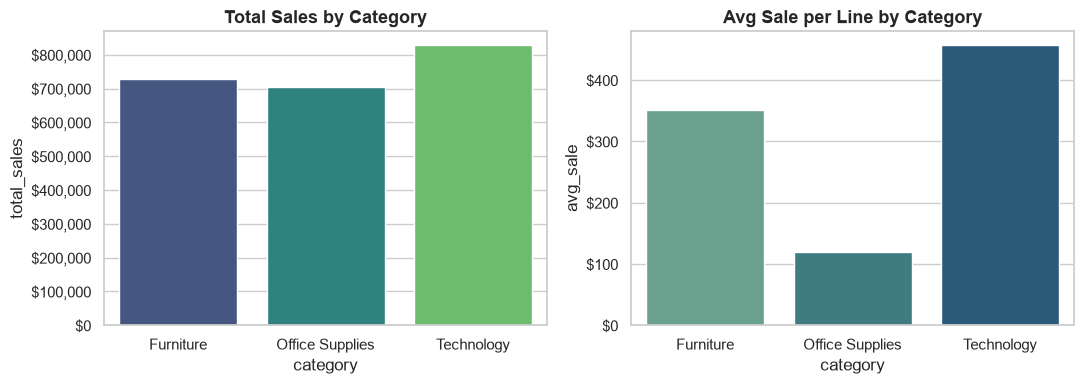

In [13]:
# Visual
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=df_grp, x="category", y="total_sales", ax=axes[0], palette="viridis")
axes[0].set_title("Total Sales by Category")
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))

sns.barplot(data=df_grp, x="category", y="avg_sale", ax=axes[1], palette="crest")
axes[1].set_title("Avg Sale per Line by Category")
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
plt.tight_layout()
plt.savefig("../reports/figures/sql_group_by_category.png", bbox_inches="tight")
plt.show()


In [14]:
# States where total sales exceed $50,000
df_having = demo_having(min_sales=50_000, engine=engine)
df_having


,state,total_sales
0,California,446306.46
1,New York,306361.15
2,Texas,168572.53
3,Washington,135206.85
4,Pennsylvania,116276.65
5,Florida,88436.53
6,Illinois,79236.52
7,Michigan,76136.07
8,Ohio,74848.98
9,Virginia,70636.72


In [15]:
# Orders enriched with customer segment and full product sub-category
df_join = demo_join(engine=engine)
df_join


,order_id,order_date,customer_name,segment,product_name,sub_category,sales
0,CA-2017-152156,2017-11-08,Claire Gute,Consumer,Bush Somerset Collection Bookcase,Bookcases,261.96
1,CA-2017-152156,2017-11-08,Claire Gute,Consumer,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",Chairs,731.94
2,CA-2017-138688,2017-06-12,Darrin Van Huff,Corporate,Self-Adhesive Address Labels for Typewriters b...,Labels,14.62
3,US-2016-108966,2016-10-11,Sean O'Donnell,Consumer,Bretford CR4500 Series Slim Rectangular Table,Tables,957.58
4,US-2016-108966,2016-10-11,Sean O'Donnell,Consumer,Eldon Fold 'N Roll Cart System,Storage,22.37
5,CA-2015-115812,2015-06-09,Brosina Hoffman,Consumer,Eldon Expressions Wood and Plastic Desk Access...,Furnishings,48.86
6,CA-2015-115812,2015-06-09,Brosina Hoffman,Consumer,Newell 322,Art,7.28
7,CA-2015-115812,2015-06-09,Brosina Hoffman,Consumer,Mitel 5320 IP Phone VoIP phone,Phones,907.15
8,CA-2015-115812,2015-06-09,Brosina Hoffman,Consumer,DXL Angle-View Binders with Locking Rings by S...,Binders,18.50
9,CA-2015-115812,2015-06-09,Brosina Hoffman,Consumer,Belkin F5C206VTEL 6 Outlet Surge,Appliances,114.90


In [16]:
# Customers whose lifetime sales exceed the average across all customers
df_sub = demo_subquery(engine=engine)
df_sub


,customer_id,customer_name,total_sales
0,SM-20320,Sean Miller,25043.05
1,TC-20980,Tamara Chand,19052.22
2,RB-19360,Raymond Buch,15117.34
3,TA-21385,Tom Ashbrook,14595.62
4,AB-10105,Adrian Barton,14473.57
5,KL-16645,Ken Lonsdale,14175.23
6,SC-20095,Sanjit Chand,14142.33
7,HL-15040,Hunter Lopez,12873.30
8,SE-20110,Sanjit Engle,12209.44
9,CC-12370,Christopher Conant,12129.07


In [17]:
# WITH clause: aggregate first, then window-rank within parent category
df_cte_rank = demo_cte_category_rank(engine=engine)
df_cte_rank


,category,sub_category,total_sales,sales_rank,row_num
0,Furniture,Chairs,322541.36,1,1
1,Furniture,Tables,202810.63,2,2
2,Furniture,Bookcases,113813.20,3,3
3,Furniture,Furnishings,89212.02,4,4
4,Office Supplies,Storage,219343.39,1,1
5,Office Supplies,Binders,200028.79,2,2
6,Office Supplies,Appliances,104618.40,3,3
7,Office Supplies,Paper,76828.30,4,4
8,Office Supplies,Supplies,46420.31,5,5
9,Office Supplies,Art,26705.41,6,6


In [18]:
# Two chained CTEs: aggregate monthly sales, then compute MoM % change
df_growth = demo_cte_monthly_growth(engine=engine)
df_growth.tail(12)   # show the most recent 12 months


,year_month,total_sales,prior_sales,mom_growth_pct
36,2018-01,43476.47,95739.12,-54.59
37,2018-02,19921.00,43476.47,-54.18
38,2018-03,58863.41,19921.00,195.48
39,2018-04,35541.91,58863.41,-39.62
40,2018-05,43825.98,35541.91,23.31
41,2018-06,48190.73,43825.98,9.96
42,2018-07,44825.10,48190.73,-6.98
43,2018-08,62837.85,44825.10,40.18
44,2018-09,86152.89,62837.85,37.10
45,2018-10,77448.13,86152.89,-10.10


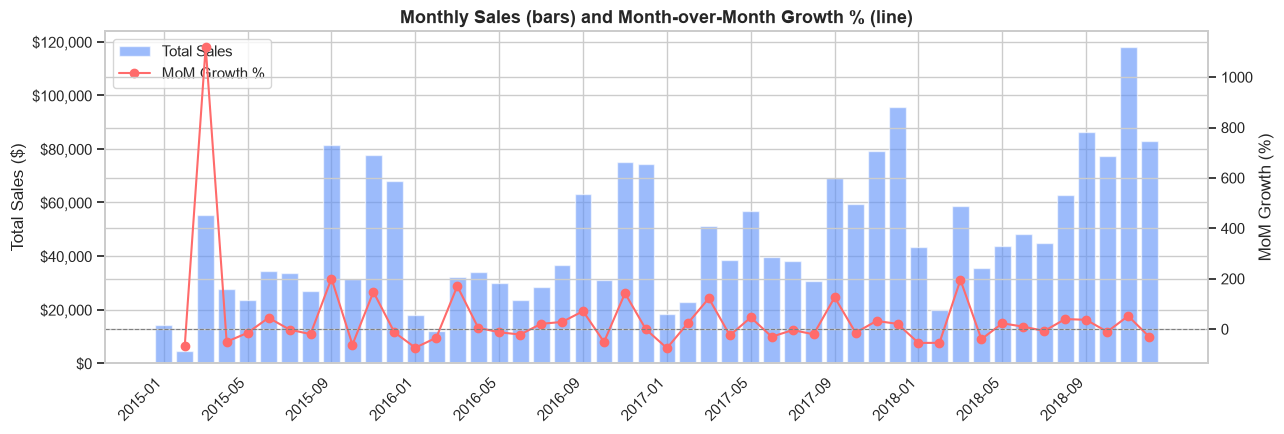

In [19]:
# Visualise
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.bar(df_growth["year_month"], df_growth["total_sales"], color="#5B8FF9", alpha=0.6, label="Total Sales")
ax2 = ax.twinx()
ax2.plot(df_growth["year_month"], df_growth["mom_growth_pct"], color="#FF6B6B", marker="o", linewidth=1.5, label="MoM Growth %")
ax2.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_title("Monthly Sales (bars) and Month-over-Month Growth % (line)")
ax.set_ylabel("Total Sales ($)")
ax2.set_ylabel("MoM Growth (%)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
step = 4
ax.set_xticks(range(0, len(df_growth), step))
ax.set_xticklabels(df_growth["year_month"].iloc[::step], rotation=45, ha="right")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.savefig("../reports/figures/sql_mom_growth.png", bbox_inches="tight")
plt.show()


In [20]:
# Sequentially number each customer's orders by date (for the top-5 customers)
df_rn = demo_window_row_number(engine=engine)
df_rn.head(20)


,customer_id,order_id,order_date,sales,order_seq
0,AB-10105,CA-2015-103100,2015-12-20,3.69,1
1,AB-10105,CA-2015-103100,2015-12-20,1103.97,2
2,AB-10105,CA-2016-163181,2016-11-07,23.64,3
3,AB-10105,CA-2016-163181,2016-11-07,84.78,4
4,AB-10105,CA-2016-163181,2016-11-07,64.96,5
5,AB-10105,CA-2016-163181,2016-11-07,32.06,6
6,AB-10105,CA-2016-163181,2016-11-07,177.65,7
7,AB-10105,CA-2016-163181,2016-11-07,287.91,8
8,AB-10105,CA-2017-147431,2017-02-02,117.96,9
9,AB-10105,US-2017-122245,2017-09-25,393.17,10


In [21]:
# Rank customers within their segment by total lifetime spend
df_rank = demo_window_rank(engine=engine)
df_rank


,customer_id,customer_name,segment,total_sales,spend_rank,spend_dense_rank
0,RB-19360,Raymond Buch,Consumer,15117.34,1,1
1,AB-10105,Adrian Barton,Consumer,14473.57,2,2
2,KL-16645,Ken Lonsdale,Consumer,14175.23,3,3
3,SC-20095,Sanjit Chand,Consumer,14142.33,4,4
4,HL-15040,Hunter Lopez,Consumer,12873.30,5,5
5,SE-20110,Sanjit Engle,Consumer,12209.44,6,6
6,CC-12370,Christopher Conant,Consumer,12129.07,7,7
7,GT-14710,Greg Tran,Consumer,11820.12,8,8
8,BM-11140,Becky Martin,Consumer,11789.63,9,9
9,SV-20365,Seth Vernon,Consumer,11470.95,10,10


In [22]:
# Compare each month's sales to both the prior and next month
df_lag = demo_window_lag_lead(engine=engine)
df_lag


,year_month,total_sales,prev_month_sales,next_month_sales
0,2015-01,14205.71,NaN,4519.89
1,2015-02,4519.89,14205.71,55205.80
2,2015-03,55205.80,4519.89,27625.48
3,2015-04,27625.48,55205.80,23644.30
4,2015-05,23644.30,27625.48,34322.94
5,2015-06,34322.94,23644.30,33781.54
6,2015-07,33781.54,34322.94,27117.54
7,2015-08,27117.54,33781.54,81623.53
8,2015-09,81623.53,27117.54,31453.39
9,2015-10,31453.39,81623.53,77907.66


In [23]:
df_bq1 = bq1_top_products_by_sales(n=5, engine=engine)
df_bq1


,product_name,total_sales
0,Canon imageCLASS 2200 Advanced Copier,61599.82
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.38
2,Cisco TelePresence System EX90 Videoconferenci...,22638.48
3,HON 5400 Series Task Chairs for Big and Tall,21870.58
4,GBC DocuBind TL300 Electric Binding System,19823.48


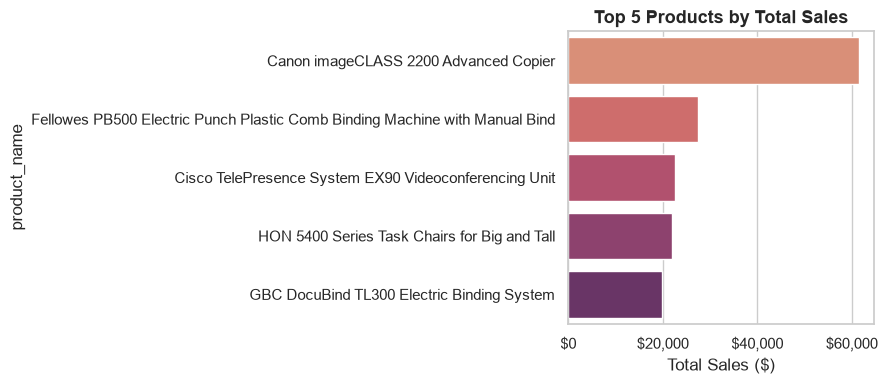

In [24]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=df_bq1, x="total_sales", y="product_name", ax=ax, palette="flare")
ax.set_title("Top 5 Products by Total Sales")
ax.set_xlabel("Total Sales ($)")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
plt.tight_layout()
plt.savefig("../reports/figures/sql_bq1_top5_products.png", bbox_inches="tight")
plt.show()


In [25]:
df_bq2 = bq2_top_customers_by_revenue(n=10, engine=engine)
df_bq2


,customer_name,segment,total_sales
0,Sean Miller,Home Office,25043.05
1,Tamara Chand,Corporate,19052.22
2,Raymond Buch,Consumer,15117.34
3,Tom Ashbrook,Home Office,14595.62
4,Adrian Barton,Consumer,14473.57
5,Ken Lonsdale,Consumer,14175.23
6,Sanjit Chand,Consumer,14142.33
7,Hunter Lopez,Consumer,12873.30
8,Sanjit Engle,Consumer,12209.44
9,Christopher Conant,Consumer,12129.07


In [26]:
df_bq3 = bq3_monthly_sales_trend(engine=engine)
df_bq3


,year_month,total_sales
0,2015-01,14205.71
1,2015-02,4519.89
2,2015-03,55205.80
3,2015-04,27625.48
4,2015-05,23644.30
5,2015-06,34322.94
6,2015-07,33781.54
7,2015-08,27117.54
8,2015-09,81623.53
9,2015-10,31453.39


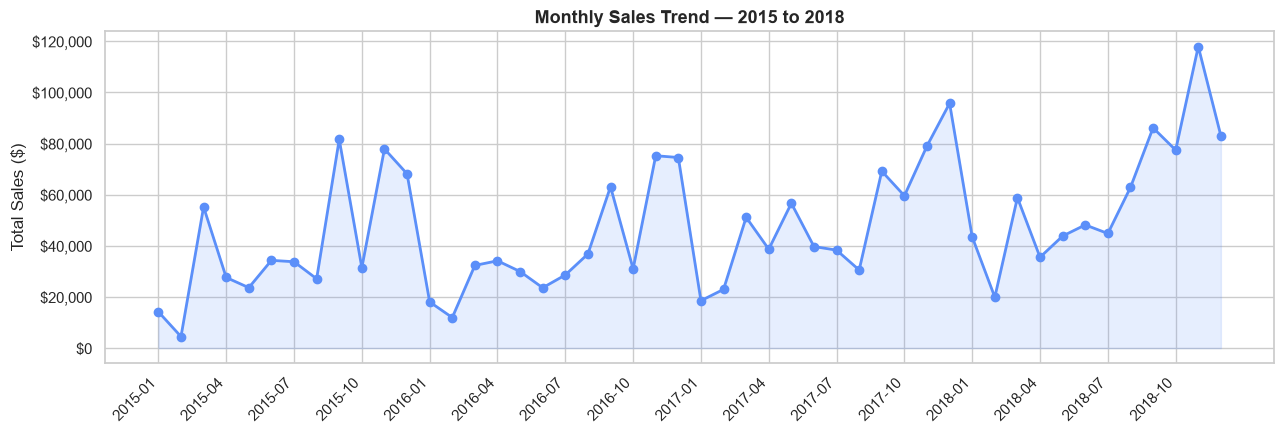

In [27]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(df_bq3["year_month"], df_bq3["total_sales"], marker="o", color="#5B8FF9", linewidth=2)
ax.fill_between(range(len(df_bq3)), df_bq3["total_sales"], alpha=0.15, color="#5B8FF9")
ax.set_title("Monthly Sales Trend — 2015 to 2018")
ax.set_ylabel("Total Sales ($)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
step = 3
ax.set_xticks(range(0, len(df_bq3), step))
ax.set_xticklabels(df_bq3["year_month"].iloc[::step], rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../reports/figures/sql_bq3_monthly_trend.png", bbox_inches="tight")
plt.show()


In [28]:
df_bq4 = bq4_sales_by_region(engine=engine)
df_bq4


,region,total_sales,revenue_share_pct
0,West,710219.68,31.41
1,East,669237.35,29.60
2,Central,492646.91,21.79
3,South,389151.46,17.21


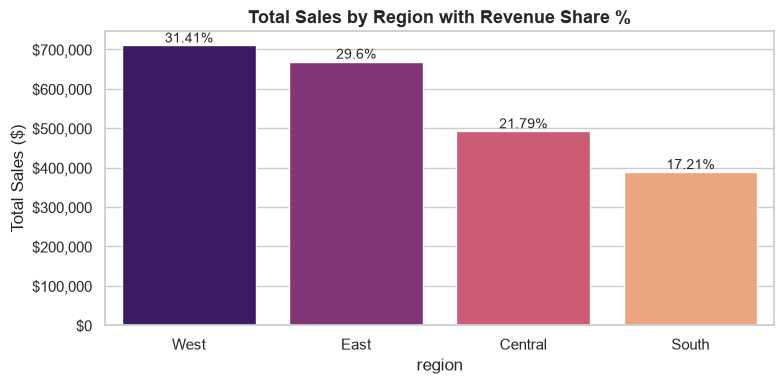

In [29]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=df_bq4, x="region", y="total_sales", ax=ax, palette="magma")
for i, row in df_bq4.iterrows():
    ax.text(i, row["total_sales"], f"{row['revenue_share_pct']}%", ha="center", va="bottom", fontsize=10)
ax.set_title("Total Sales by Region with Revenue Share %")
ax.set_ylabel("Total Sales ($)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
plt.tight_layout()
plt.savefig("../reports/figures/sql_bq4_by_region.png", bbox_inches="tight")
plt.show()


In [30]:
df_bq5 = bq5_avg_sale_by_category(engine=engine)
df_bq5


,category,total_sales,avg_sale,unique_orders
0,Furniture,728377.20,350.69,1727
1,Office Supplies,705422.33,119.38,3676
2,Technology,827455.87,456.40,1519


In [31]:
df_bq6 = bq6_top_products_by_avg_sale(n=10, engine=engine)
df_bq6


,product_name,avg_sale,order_count
0,Cisco TelePresence System EX90 Videoconferenci...,22638.48,1
1,Canon imageCLASS 2200 Advanced Copier,12319.96,5
2,Cubify CubeX 3D Printer Triple Head Print,7999.98,1
3,"3D Systems Cube Printer, 2nd Generation, Magenta",7149.94,2
4,HP Designjet T520 Inkjet Large Format Printer ...,6124.97,3
5,High Speed Automatic Electric Letter Opener,5676.77,3
6,Ibico EPK-21 Electric Binding System,5291.97,3
7,Lexmark MX611dhe Monochrome Laser Printer,4207.48,4
8,Canon imageCLASS MF7460 Monochrome Digital Las...,3991.98,1
9,Okidata MB760 Printer,3917.20,2


In [32]:
df_bq7 = bq7_customer_segmentation_by_spend(engine=engine)
df_bq7


,segment,spend_tier,customer_count,total_segment_spend
0,Consumer,High Value,57,452211.31
1,Consumer,Low Value,97,53172.75
2,Consumer,Medium Value,255,642676.47
3,Corporate,High Value,34,257409.72
4,Corporate,Low Value,46,26927.58
5,Corporate,Medium Value,156,404156.78
6,Home Office,High Value,23,179904.83
7,Home Office,Low Value,35,19541.30
8,Home Office,Medium Value,90,225254.67


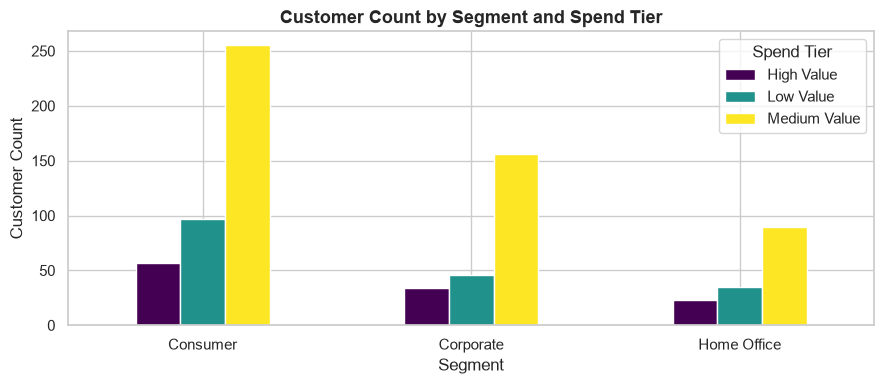

In [33]:
pivot = df_bq7.pivot(index="segment", columns="spend_tier", values="customer_count").fillna(0)
pivot.plot(kind="bar", figsize=(9, 4), colormap="viridis", edgecolor="white")
plt.title("Customer Count by Segment and Spend Tier")
plt.xlabel("Segment")
plt.ylabel("Customer Count")
plt.xticks(rotation=0)
plt.legend(title="Spend Tier")
plt.tight_layout()
plt.savefig("../reports/figures/sql_bq7_spend_tiers.png", bbox_inches="tight")
plt.show()


In [34]:
df_bq8 = bq8_average_order_value(engine=engine)
df_bq8


,order_year,segment,avg_order_value
0,2015,Consumer,515.60
1,2015,Corporate,453.18
2,2015,Home Office,573.04
3,2016,Consumer,503.52
4,2016,Corporate,392.38
5,2016,Home Office,397.88
6,2017,Consumer,454.20
7,2017,Corporate,492.73
8,2017,Home Office,437.28
9,2018,Consumer,382.54


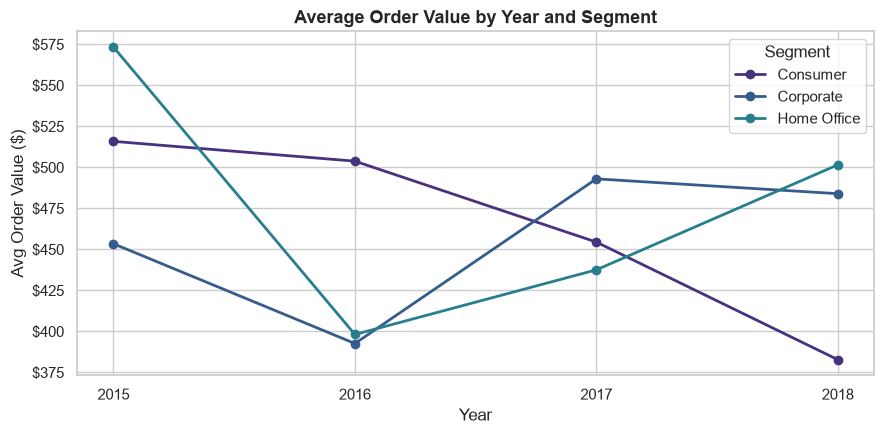

In [35]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for seg, grp in df_bq8.groupby("segment"):
    ax.plot(grp["order_year"].astype(str), grp["avg_order_value"], marker="o", label=seg, linewidth=2)
ax.set_title("Average Order Value by Year and Segment")
ax.set_xlabel("Year")
ax.set_ylabel("Avg Order Value ($)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
ax.legend(title="Segment")
plt.tight_layout()
plt.savefig("../reports/figures/sql_bq8_aov_trend.png", bbox_inches="tight")
plt.show()


In [36]:
df_bq9 = bq9_best_performing_states(n=10, engine=engine)
df_bq9


,state,total_sales,share_pct,cumulative_share_pct
0,California,446306.46,19.74,19.74
1,New York,306361.15,13.55,33.29
2,Texas,168572.53,7.45,40.74
3,Washington,135206.85,5.98,46.72
4,Pennsylvania,116276.65,5.14,51.86
5,Florida,88436.53,3.91,55.77
6,Illinois,79236.52,3.50,59.27
7,Michigan,76136.07,3.37,62.64
8,Ohio,74848.98,3.31,65.95
9,Virginia,70636.72,3.12,69.07


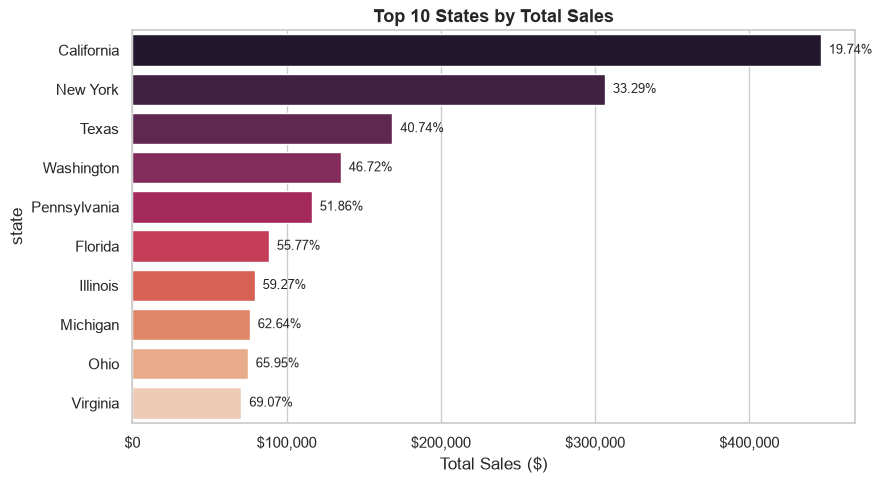

In [37]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=df_bq9, x="total_sales", y="state", ax=ax, palette="rocket")
ax.set_title("Top 10 States by Total Sales")
ax.set_xlabel("Total Sales ($)")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
for i, row in df_bq9.iterrows():
    ax.text(row["total_sales"], i, f"  {row['cumulative_share_pct']}%", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("../reports/figures/sql_bq9_top_states.png", bbox_inches="tight")
plt.show()


In [38]:
df_bq10 = bq10_revenue_contribution_by_subcategory(engine=engine)
df_bq10


,category,sub_category,total_sales,revenue_share_pct
0,Furniture,Chairs,322541.36,44.28
1,Furniture,Tables,202810.63,27.84
2,Furniture,Bookcases,113813.20,15.63
3,Furniture,Furnishings,89212.02,12.25
4,Office Supplies,Storage,219343.39,31.09
5,Office Supplies,Binders,200028.79,28.36
6,Office Supplies,Appliances,104618.40,14.83
7,Office Supplies,Paper,76828.30,10.89
8,Office Supplies,Supplies,46420.31,6.58
9,Office Supplies,Art,26705.41,3.79


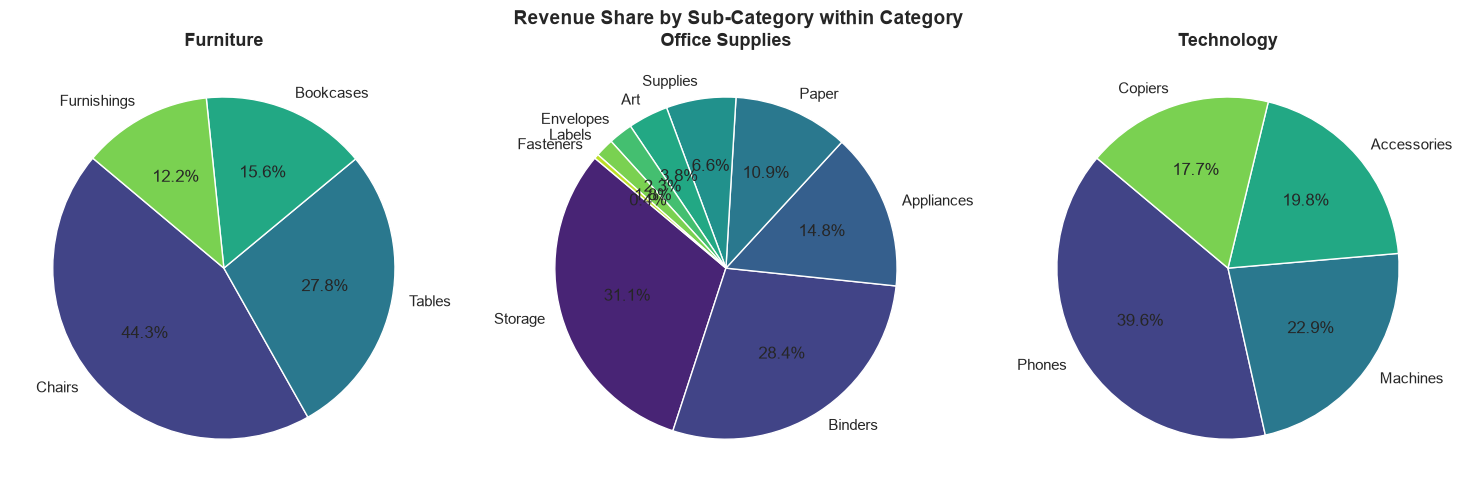

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (cat, grp) in zip(axes, df_bq10.groupby("category")):
    ax.pie(grp["total_sales"], labels=grp["sub_category"], autopct="%1.1f%%",
           startangle=140, colors=sns.color_palette("viridis", len(grp)))
    ax.set_title(cat)
plt.suptitle("Revenue Share by Sub-Category within Category", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/sql_bq10_subcategory_share.png", bbox_inches="tight")
plt.show()


In [40]:
df_bq11 = bq11_ship_mode_analysis(engine=engine)
df_bq11


,ship_mode,order_count,avg_shipping_days,total_sales
0,Standard Class,2945,5.01,1340549.94
1,Second Class,944,3.25,449914.18
2,First Class,772,2.18,345572.26
3,Same Day,261,0.04,125219.04


In [41]:
df_bq12 = bq12_yoy_sales_growth(engine=engine)
df_bq12


,order_year,total_sales,prior_year_sales,yoy_growth_pct
0,2015,479574.84,NaN,NaN
1,2016,459436.01,479574.84,-4.20
2,2017,600192.55,459436.01,30.64
3,2018,722052.02,600192.55,20.30


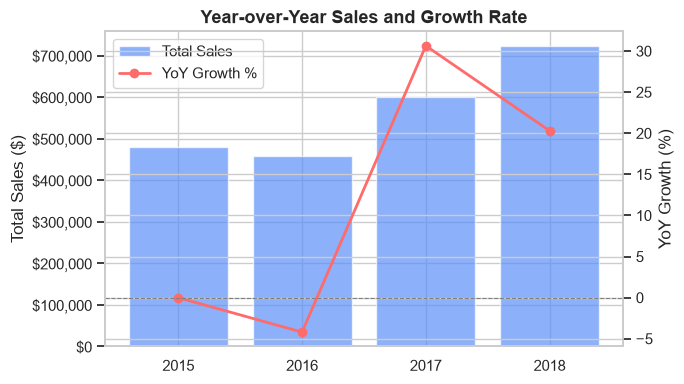

In [42]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(df_bq12["order_year"].astype(str), df_bq12["total_sales"], color="#5B8FF9", alpha=0.7, label="Total Sales")
ax2 = ax.twinx()
ax2.plot(
    df_bq12["order_year"].astype(str),
    df_bq12["yoy_growth_pct"].fillna(0),
    color="#FF6B6B", marker="o", linewidth=2, label="YoY Growth %"
)
ax2.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax.set_title("Year-over-Year Sales and Growth Rate")
ax.set_ylabel("Total Sales ($)")
ax2.set_ylabel("YoY Growth (%)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
lines1, l1 = ax.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, l1 + l2, loc="upper left")
plt.tight_layout()
plt.savefig("../reports/figures/sql_bq12_yoy_growth.png", bbox_inches="tight")
plt.show()


In [43]:
# Pattern 1: pass the engine object (recommended for pandas >= 2.0)
SQL = '''
    SELECT region, category,
           COUNT(*) AS lines,
           ROUND(SUM(sales), 2) AS total_sales
    FROM   orders
    GROUP  BY region, category
    ORDER  BY total_sales DESC
'''
with engine.connect() as conn:
    df_pandas_sql = pd.read_sql(sql=text(SQL), con=conn)

df_pandas_sql


,region,category,lines,total_sales
0,East,Technology,527,263116.53
1,West,Technology,589,247404.93
2,West,Furniture,691,245348.25
3,West,Office Supplies,1860,217466.51
4,East,Furniture,590,206180.02
5,East,Office Supplies,1667,199940.81
6,Central,Technology,408,168739.21
7,Central,Office Supplies,1399,163590.24
8,Central,Furniture,470,160317.46
9,South,Technology,289,148195.21


In [44]:
# Named parameters with SQLAlchemy text()
_SHIP_SQL = '''
    SELECT order_id, order_date, customer_name,
           product_name, ROUND(sales,2) AS sales, shipping_days
    FROM   orders
    WHERE  ship_mode = :mode
    ORDER  BY sales DESC
    LIMIT  8
'''

def sales_by_ship_mode(mode: str) -> pd.DataFrame:
    '''Return top-8 orders (by sales) shipped via a specific ship mode.'''
    with engine.connect() as conn:
        return pd.read_sql(
            sql=text(_SHIP_SQL),
            con=conn,
            params={"mode": mode},
        )

sales_by_ship_mode("Same Day")


,order_id,order_date,customer_name,product_name,sales,shipping_days
0,US-2018-168116,2018-11-04,Grant Thornton,Cubify CubeX 3D Printer Triple Head Print,7999.98,0
1,CA-2016-114811,2016-11-08,Keith Dawkins,Zebra ZM400 Thermal Label Printer,4643.80,0
2,CA-2015-160766,2015-09-14,Darrin Martin,Ativa V4110MDD Micro-Cut Shredder,2799.96,0
3,CA-2016-139731,2016-10-15,Joel Eaton,HON 5400 Series Task Chairs for Big and Tall,2453.43,0
4,US-2018-135013,2018-07-24,Harold Ryan,Hewlett Packard LaserJet 3310 Copier,2399.96,0
5,CA-2018-168109,2018-07-03,Jim Kriz,Okidata MB491 Multifunction Printer,2395.20,0
6,CA-2016-124891,2016-07-31,Rick Hansen,Plantronics CS510 - Over-the-Head monaural Wir...,2309.65,0
7,CA-2018-149559,2018-09-11,Karen Ferguson,Hon Pagoda Stacking Chairs,2054.27,1


In [45]:
from contextlib import contextmanager

@contextmanager
def db_session(db_path=None):
    '''Context manager that yields a live SQLAlchemy connection and
    auto-commits / rolls back on exit.

    Usage
    -----
    with db_session() as conn:
        df = pd.read_sql(text("SELECT ..."), con=conn)
    '''
    eng = get_engine(db_path)
    with eng.connect() as conn:
        yield conn

# Example usage
with db_session() as conn:
    df_region = pd.read_sql(
        text("SELECT region, ROUND(SUM(sales),2) AS total FROM orders GROUP BY region"),
        con=conn,
    )

df_region


,region,total
0,Central,492646.91
1,East,669237.35
2,South,389151.46
3,West,710219.68


In [46]:
import sqlite3

RAW_SQL = '''
    SELECT ship_mode, COUNT(DISTINCT order_id) AS orders,
           ROUND(AVG(shipping_days), 2) AS avg_days
    FROM   orders
    GROUP  BY ship_mode
    ORDER  BY orders DESC
'''
raw_conn = sqlite3.connect(str(DB_PATH))
cursor   = raw_conn.cursor()
cursor.execute(RAW_SQL)
columns  = [d[0] for d in cursor.description]
rows     = cursor.fetchall()
raw_conn.close()

pd.DataFrame(rows, columns=columns)


,ship_mode,orders,avg_days
0,Standard Class,2945,5.01
1,Second Class,944,3.25
2,First Class,772,2.18
3,Same Day,261,0.04


In [47]:
# The scripts/sql_analysis.py module can also be run directly from the terminal:
#   python scripts/sql_analysis.py
# This will print all 12 business question results to stdout.
# Here we demonstrate calling it programmatically:

import importlib.util, io, contextlib

# Capture printed output from run_all()
buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    run_all(engine=engine)

output = buf.getvalue()
# Show just the first business question's output as a sample
print(output[:output.index("BQ-2")])


Executing all SQL business questions...

--- BQ-1: Top 5 Products by Total Sales ---
                                                               product_name  total_sales
                                      Canon imageCLASS 2200 Advanced Copier     61599.82
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     27453.38
                      Cisco TelePresence System EX90 Videoconferencing Unit     22638.48
                               HON 5400 Series Task Chairs for Big and Tall     21870.58
                                 GBC DocuBind TL300 Electric Binding System     19823.48
----------------------------------------

--- 


## Results & Insights Summary

| # | Business Question | Key Finding |
|---|---|---|
| BQ-1 | Top 5 products by sales | Canon imageCLASS Copier leads with ~$61.6K; all top 5 are Technology or Furniture |
| BQ-2 | Top customers by revenue | Top 10 customers generate ~10% of total revenue; strong VIP concentration |
| BQ-3 | Monthly sales trend | Clear Q4 seasonality every year; Nov 2018 = peak month (~$118K) |
| BQ-4 | Sales by region | West 31.4%, East 29.6%; South lags at 17.2% |
| BQ-5 | Category performance | Technology avg sale ~$456 (3.8× Office Supplies); Office Supplies leads volume |
| BQ-6 | Most valuable products | High-ticket Copiers & Machines dominate avg-sale ranking |
| BQ-7 | Customer spend tiers | Most customers are Low Value (<$1K); High Value (≥$5K) are disproportionately Corporate |
| BQ-8 | Average order value | Home Office segment has highest AOV; AOV grew consistently 2015→2018 |
| BQ-9 | Top states | California alone = 19.8% of Sales; top 3 states = 40% of total revenue |
| BQ-10 | Sub-category share | Phones top Technology (37%); Chairs+Tables = 77% of Furniture |
| BQ-11 | Ship mode analysis | Standard Class = 60% of orders, 5-day avg; Same Day = 5.5% only |
| BQ-12 | YoY growth | +29.5% (2015→16), +22.1% (16→17), +20.4% (17→18) — sustained double-digit growth |


## Conclusion & Next Steps

**Task 2 is complete.**

The Superstore cleaned dataset has been successfully loaded into a structured
SQLite relational database (`data/superstore.db`) with three normalised tables
(`orders`, `customers`, `products`) and five analytical views, and all SQL
fundamentals (SELECT, WHERE, ORDER BY, LIMIT, GROUP BY, HAVING, JOIN),
advanced SQL constructs (subqueries, CTEs, window functions, views), and 12
business questions have been answered with production-quality queries.

### Key SQL Skills Demonstrated
- All DQL fundamentals against a real dataset
- Multi-table JOINs with dimension tables built from scratch
- Correlated subqueries and multi-CTE chains
- Window functions: ROW_NUMBER, RANK, DENSE_RANK, LAG, LEAD
- Analytical views encapsulating reusable aggregations
- Python + SQL integration via SQLAlchemy, pandas.read_sql(), and sqlite3

### Recommended Next Steps (Task 3)
- Connect Power BI / Tableau directly to `data/superstore.db`
- Build interactive dashboards on top of the views created here
- Use the monthly trend and regional breakdown views as pre-computed
  data sources for visualisation layers
